# Stage 01 — the AUROR_ref job, driven by a run spec

This notebook takes its run from a versioned **MANIFOLD run-spec YAML**,
`run_specs/auror_ref.yaml`, not from values written into its cells. The YAML is authored in
eopticDocs (`projects/MANIFOLD/04-guides/auror_ref_run_spec.yaml`, documented by
`GD_DIRSIG_RunSpec_YAML_v01.md`) and vendored here. `protodirsig.run_spec` reads it and resolves
the scene, platform, atmosphere, weather and ephemeris references, and the run seed. The scene,
platform, atmosphere database and weather come from `config_repo/`, the engine-asset library
(since Stage 04). The motion and tasks files are generated from the run spec (since Stage 05).
Nothing is read from a received run tree.

This is **staged implementation** toward a MANIFOLD-aligned generator, not a tutorial. For dirfm
usage itself, see `tutorial_dirfm_basics`, `tutorial_orbit_to_ground` and `tutorial_tacoma_scene`.
Stage notebooks are numbered `stage_NN_<slug>` independently of the tutorials.

**What the run is.** The job came from `AUROR_ref/`, a received DIRSIG run tree (now trimmed
to a test fixture, `tests/fixtures/auror_ref/`), a **static-pose detection scene**. A NIR sensor hangs 550 km above a Lake Tahoe terrain tile (39° N, −120° E), looking
straight down at an embedded ~2 m vehicle target 50 km up. The job reproduces the tree's one
surviving simulation, `jsims/AurorSimulation.jsim`, and runs it on this machine's DIRSIG install.
It renders one frame from one fixed geometry.

**What the run spec drives.** `engine.scenes`, `platform`, `atmosphere`, `weather`,
`ephemeris` and `run.seed` name library files and plugin choices. `engine.motion` (`kind:
static`) and `engine.tasks` are generated into the job directory by `protodirsig.motion_tasks`,
using dirfm's `PlatformPosition` and `TASKS` (FINDINGS.md, "2026-10-08 — Stage 05").

Nothing under `config_repo/` is modified. The scene is referenced through the read-only
pattern, every other library input is a byte-identical copy, and `config_repo/` is fingerprinted
around the render. How
the dirfm workarounds were found is in `notebooks/dev/auror_scene_buildup.ipynb` (local) and
FINDINGS.md ("2026-10-06 — Phase 5").

| Piece | From |
|---|---|
| Run spec → resolved library files, plugin choices, seed; spec-vs-file check | `protodirsig.run_spec` |
| Motion (`.ppd`) and tasks (`.tasks`) generated from the run spec | `protodirsig.motion_tasks` |
| Scene reference (XML copy + asset symlinks), input copies, fingerprint guard | `protodirsig.scene_ref` |
| Band coverage of the scene's real materials, including bundle materials | `protodirsig.scene_coverage` |
| `BasicPlatform` from `.platform`/`.ppd`/`.tasks` files; `SpiceEphemeris` with no inputs | `protodirsig.platform_ref` |
| `NewAtmosphere` over an existing database | `protodirsig.atmosphere_patches` |
| `ThermWeather` from a weather file | `dirfm.weather.ThermWeatherFilePlugin` |

| Stage | What it does |
|---|---|
| 0 | Load the run spec; reference the scene; check its materials cover the sensor band |
| 1 | Build the four plugins from the run spec and assemble the job |
| 2 | Render, then look at the image and the geolocation truth |

---
# Stage 0 — The run spec and the scene

## Environment

This uses the same convention as the other notebooks. `DIRSIG_HOME` comes from the environment,
with this machine's install as the fallback, and its `bin/` goes on `PATH`. `protodirsig` is
imported from `src/`.

In [1]:
import os
import shutil
import sys
from pathlib import Path

DEFAULT_DIRSIG_HOME = Path.home() / "DIRSIG" / "dirsig-2026.38.0.a020954-Linux-x86_64"
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME", DEFAULT_DIRSIG_HOME)).expanduser()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), "DIRSIG binaries not on PATH"

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = PROJECT / "outputs"
IN_DIR, OUT_DIR = OUTPUTS / "stage_01_auror_input", OUTPUTS / "stage_01_auror_output"

try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig

RUN_SPEC = PROJECT / "run_specs" / "auror_ref.yaml"     # vendored; edit in eopticDocs 04-guides/
print("DIRSIG_HOME :", DIRSIG_HOME)
print("run spec    :", RUN_SPEC.relative_to(PROJECT))
CONFIG_REPO = PROJECT / "config_repo"                    # read-only engine-asset library
print("config_repo :", CONFIG_REPO, "exists" if CONFIG_REPO.is_dir() else "MISSING")
assert RUN_SPEC.is_file() and CONFIG_REPO.is_dir()

DIRSIG_HOME : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
run spec    : run_specs/auror_ref.yaml
config_repo : /home/kevin-kearney/dev/protoDIRSIG/config_repo exists


## Loading the run spec

`load_run_spec` parses the YAML. `resolve_auror_run` resolves its references and collects the
values motion and tasks are generated from:

* `scenes[0]`, `platform`, `atmosphere.database` and `weather.file` are paths in `config_repo/`,
  the engine-asset library (guide §9). `scenes/tahoe/tahoe.scene` names the `.scene` file
  itself, with `geometry/` and `materials/` beside it. There's no fallback search (Stage 04).
* `atmosphere.plugin: new_atmosphere` is a proposed, **non-adopted** extension to
  `dirsig-engine/1`, which defines only `four_curve` and `basic`. The loader accepts only this
  value. Its MODTRAN-tape backend recipe isn't in the run spec, so the loader supplies the
  received jsim's.
* `motion` and `tasks` name no files; their values are generated into files below. Only
  `kind: static` with a scene-frame position and a `sceneenu` Euler orientation is accepted,
  because that is all dirfm's `PlatformPosition` writes. `waypoints`, `orbit` and `lookat` need
  `FlexMotion` and are refused.
* `check_library_files` compares the one value the spec restates from a library file:
  `integration_samples` against the platform file.

In [2]:
from protodirsig.run_spec import check_library_files, load_run_spec, resolve_auror_run

spec = load_run_spec(RUN_SPEC)
run = resolve_auror_run(spec, RUN_SPEC, CONFIG_REPO)
mismatches = check_library_files(spec, run)

rel = lambda p: f"config_repo/{p.relative_to(CONFIG_REPO).as_posix()}"
print(f"meta.name   : {run.name}")
print(f"origin      : {run.origin}")
print(f"atmosphere  : {spec['engine']['atmosphere']['plugin']} (non-adopted dirsig-engine/1 extension), "
      f"database {rel(run.atmosphere_db)}")
print(f"scene       : {spec['engine']['scenes'][0]['ref']['name']} -> {rel(run.scene)}, offset {run.scene_offset}")
print(f"platform    : {rel(run.platform)}")
print(f"motion      : generated: static, scene {run.motion_position}, euler {run.motion_orientation['order']} "
      f"{run.motion_orientation['angles']} {run.motion_orientation['units']} (sceneenu)")
print(f"tasks       : generated: epoch {run.epoch.isoformat()}, windows {run.tasks_windows}")
print(f"weather     : {rel(run.weather)}; ephemeris {run.ephemeris}; seed {run.seed}")
print(f"spec vs library platform (integration_samples): {'agree' if not mismatches else mismatches}")
assert not mismatches

meta.name   : auror-ref-static-pose
origin      : {'kind': 'synthetic', 'engine': 'dirsig'}
atmosphere  : new_atmosphere (non-adopted dirsig-engine/1 extension), database config_repo/atmosphere/AurorNewAtmosphere
scene       : scenes/tahoe/tahoe.scene -> config_repo/scenes/tahoe/tahoe.scene, offset [0, 0, 0]
platform    : config_repo/platforms/AurorNIRDetector/AurorNIRDetector.platform
motion      : generated: static, scene [-400.0, 400.0, 550000.0], euler xyz [0.0, 0.0, 3.141592654] radians (sceneenu)
tasks       : generated: epoch 2009-07-27T19:29:32+00:00, windows [(0.0, 0.0)]
weather     : config_repo/weather/saw.wth; ephemeris spice; seed 42
spec vs library platform (integration_samples): agree


## Referencing `tahoe.scene`

As in the Tacoma notebook, `scene_ref.reference_scene` copies only the run spec's resolved
`.scene` XML into the job's directory, beside symlinks to its `geometry/`, `materials/` and
`maps/` folders. Setting dirfm's `SCENE._fname` to that copy makes `SCENE.write()` return the
path untouched. The scene's assets, including the vehicle bundle under
`geometry/bundles/hypersonic/`, are read in place through `$SCENE_DIR`, and `scene2hdf` writes its
output next to the copy, not into `AUROR_ref/`.

What the scene contains, from its XML:

* `features="vis,nir,swir,sources,exoatm"`;
* a terrain OBJ (`lists/terrain.glist`), all material 1, "Terrain (proxy)". The material and
  texture maps are disabled, as received;
* the vehicle (`lists/hypersonic.glist`): a bundle with its own material, `Gidder_mat`, a
  1500 K emitter with zero reflectance. It is placed by a `straight` dynamic instance starting
  at scene `(-400, 400, 50000)` m.

In [3]:
import lxml.etree as et
from dirfm import SCENE
from protodirsig.scene_ref import reference_scene

if IN_DIR.exists():
    shutil.rmtree(IN_DIR)                  # our own directory; rmtree unlinks symlinks, never follows them
REF_DIR = IN_DIR / "auror_ref"
ref_file = reference_scene(run.scene, REF_DIR)

auror_scene = SCENE(run.scene.stem)
auror_scene._fname = ref_file                            # private attribute: write() returns it as-is

scene_xml = et.parse(str(ref_file)).getroot()
loc = scene_xml.find("sceneorigin/location")
LAT0, LON0, ALT0 = (float(loc.findtext(k)) for k in ("latitude", "longitude", "altitude"))
print(f"scene reference : {ref_file.relative_to(PROJECT)}")
print(f"scene origin    : {LAT0}, {LON0}, {ALT0} m; features {scene_xml.find('properties').get('features')!r}")
print(f"geometry lists  : {[g.text for g in scene_xml.iterfind('geometrylist/geometrylistinclude')]}")
print(f"maps            : {[(m.get('name'), m.get('enabled')) for m in scene_xml.find('maplist')]}")

Material [Dummy] ID has already been set to [N/A], can't override.


scene reference : outputs/stage_01_auror_input/auror_ref/tahoe.scene
scene origin    : 39.0, -120.0, 0.0 m; features 'vis,nir,swir,sources,exoatm'
geometry lists  : ['lists/terrain.glist', 'lists/hypersonic.glist']
maps            : [('Tahoe Class Map (small)', 'false'), ('Tahoe Texture Map (small)', 'false')]


## Band coverage

The sensor's bandpass is 0.41–2.0 µm (read from the platform file below). dirfm's own coverage
check can't see a `_fname` scene's materials, so `scene_coverage` reads them directly. It covers
the scene's `.mat` file and every bundle material reached through the geometry lists, which
here includes `Gidder_mat`.

In [4]:
from protodirsig.scene_coverage import scene_coverage

plat = et.parse(str(run.platform)).getroot()
bp = plat.find(".//capturemethod/spectralresponse/bandpass")
BAND = (float(bp.findtext("minimum")), float(bp.findtext("maximum")))

cov = scene_coverage(ref_file)
for m in cov.materials:
    lo, hi = m.span
    print(f"  {m.id:>10s}  {m.name:22s} {lo:.2f}-{hi:.2f} um   ({m.source.name})")
print(f"sensor band {BAND[0]}-{BAND[1]} um covered by every material: {cov.covers(*BAND)}")
assert cov.covers(*BAND)

           1  Terrain (proxy)        0.20-20.00 um   (tahoe.mat)
          11  Water                  0.40-15.60 um   (tahoe.mat)
          12  Class #2               0.40-15.60 um   (tahoe.mat)
          13  Class #3               0.40-15.60 um   (tahoe.mat)
          14  Class #4 (asphalt)     0.40-15.60 um   (tahoe.mat)
          15  Class #5 (grass)       0.40-15.60 um   (tahoe.mat)
          16  Class #6 (coniferous)  0.40-15.60 um   (tahoe.mat)
          17  Class #7 (Pine Tree)   0.40-15.60 um   (tahoe.mat)
          18  Class #8               0.40-15.60 um   (tahoe.mat)
          19  Class #9 (concrete)    0.40-15.60 um   (tahoe.mat)
  Gidder_mat  Gidder_mat             0.40-3.00 um   (hypersonic.mat)
sensor band 0.41-2.0 um covered by every material: True


---
# Stage 1 — Plugins and assembly

The original jsim wires four plugins: `BasicPlatform`, `NewAtmosphere`, `SpiceEphemeris` and
`ThermWeather`. Each one is now built from the resolved run spec. Each library file is copied
into the job directory with `scene_ref.copy_input`, asserted byte-identical, and the motion and
tasks files are generated there, so the jsim holds relative paths into the job directory instead
of the original's Windows paths.

* **Platform, motion, tasks.** `platform_ref.PlatformFilesPlugin` emits `BasicPlatform` with the
  library platform file and the two generated files, and `split_channels` from `engine.platform`. The platform is "Auror NIR
  Detector": 500 × 500 pixels at 10 µm pitch, f = 306 mm, one Gaussian channel centred on
  0.85 µm. The motion is a single pose: 550 km above scene `(-400, 400)`, looking straight down.
  The one task is a single frame at `descriptor.collection.epoch`, `2009-07-27T19:29:32Z`,
  written in UTC (the received tasks file said `11:29:32-08:00`, the same instant, in PST for a
  July date). dirfm writes the yaw as `3.141593` (6 decimals) where the spec says `3.141592654`. `integration_samples` (10) is already in the `.platform` file; the
  check above confirmed the two agree.
* **`output_prefix` is carried but not applied.** The run spec gives `auror_nir_`, but the
  received jsim has no prefix, and `PlatformFilesPlugin` (reused as it stands) does not emit one.
  dirfm's `DIRSIG.set_output_prefix` stores a value that nothing reads. Applying it would rename
  `AurorNIROutput`/`truth1` and stop this job reproducing the received one.
* **Atmosphere.** `run.atmosphere_plugin()` builds `atmosphere_patches.PatchedNewAtmospherePlugin`
  over the job's copy of `engine.atmosphere.database` (`AurorNewAtmosphere`, beside the jsim as in
  the original). The backend block repeats the jsim's MODTRAN-tape settings. It is the recipe
  `atm_builder` would use to rebuild the database, and with an existing database it is carried
  for completeness.
* **Ephemeris.** `engine.ephemeris.plugin: spice` → `platform_ref.SpiceEphemerisPlugin`:
  `SpiceEphemeris` with no inputs, using DIRSIG's bundled kernels.
* **Weather.** `ThermWeatherFilePlugin` on `engine.weather.file`.
* **Seed.** `engine.run.seed` goes to `DIRSIG.set_seed`, which passes `--random_seed` to both
  `scene2hdf` and `dirsig5`. Earlier renders of this tree were unseeded.

In [5]:
import json
from dirfm import DIRSIG
from dirfm.weather import ThermWeatherFilePlugin
from protodirsig.motion_tasks import generate_motion, generate_tasks
from protodirsig.platform_ref import PlatformFilesPlugin
from protodirsig.scene_ref import copy_input

inputs = {name: copy_input(src, IN_DIR / src.relative_to(CONFIG_REPO)) for name, src in [
    ("platform", run.platform), ("weather", run.weather)]}
inputs["motion"] = generate_motion(run, IN_DIR / "motion")                              # from engine.motion
inputs["tasks"] = generate_tasks(run, IN_DIR / "tasks")                                 # from engine.tasks + epoch
inputs["atmosphere"] = copy_input(run.atmosphere_db, IN_DIR / run.atmosphere_db.name)   # beside the jsim

# NB: the database was built for a site in western New York (43.12 N, -78.45 E), not Tahoe; the
# received run used it as-is, so this one does too.
job = DIRSIG(IN_DIR, OUT_DIR)
job.add_plugin(PlatformFilesPlugin(inputs["platform"], inputs["motion"], inputs["tasks"],
                                   split_channels=run.split_channels))
job.add_plugin(run.atmosphere_plugin(inputs["atmosphere"]))
job.add_plugin(run.ephemeris_plugin())
job.add_plugin(ThermWeatherFilePlugin(inputs["weather"]))
job.add_scene(auror_scene, run.scene_offset)
job.set_seed(run.seed)
print(f"output_prefix {run.output_prefix!r} from the run spec: not applied (see above)")

jsim = job.write_files()                                 # builds the JSIM only; run() repeats this
jsim.write(IN_DIR / "preview.jsim")
print(json.dumps(json.loads((IN_DIR / "preview.jsim").read_text())[0], indent=1))

output_prefix 'auror_nir_' from the run spec: not applied (see above)
{
 "scene_list": [
  {
   "inputs": "auror_ref/tahoe.scene",
   "offset": "0,0,0"
  }
 ],
 "plugin_list": [
  {
   "name": "BasicPlatform",
   "inputs": {
    "platform_filename": "platforms/AurorNIRDetector/AurorNIRDetector.platform",
    "motion_filename": "motion/motion.ppd",
    "tasks_filename": "tasks/tasks.tasks",
    "split_channels": false
   }
  },
  {
   "name": "NewAtmosphere",
   "inputs": {
    "info": {
     "name": "",
     "author": "",
     "organization": "",
     "description": ""
    },
    "backend": {
     "name": "modtran_tape",
     "modtran_profile": "New Profile",
     "tape5_parameters": {
      "atmospheric_model": "MidLatitudeSummer",
      "multiple_scattering": {
       "type": "Isaac",
       "parameters": {}
      },
      "boundary_aerosol_model": {
       "type": "RuralVis23Km",
       "parameters": {}
      }
     }
    },
    "hdf_filename": "AurorNewAtmosphere"
   }
  },
  {
   

That is the original `AurorSimulation.jsim`, with its paths pointing into this job's
directory. dirfm also adds `offset: "0,0,0"` to the scene entry, which means no offset. The
seed is not in the jsim; `run()` passes it on the command line.

---
# Stage 2 — Render and inspect

`job.run()` compiles the scene with this install's `scene2hdf` into `auror_ref/` (the shipped
`AUROR_ref/tahoe.scene.hdf` is never used), then renders with `dirsig5`. As in the Tacoma
notebook, `scene_ref.fingerprint` records every path under `config_repo/` before and after
the run, and the cell asserts nothing changed. A render takes about 6 minutes on this machine.

In [6]:
import time
from protodirsig.scene_ref import fingerprint

assert not (REF_DIR / "tahoe.scene.hdf").exists()
before = fingerprint(CONFIG_REPO)
t0 = time.perf_counter()
job.run()
elapsed = time.perf_counter() - t0
after = fingerprint(CONFIG_REPO)

print(f"run() {elapsed:.0f} s")
print(f"config_repo fingerprint: {len(before)} paths, unchanged = {before == after}")
print(f"scene2hdf wrote       : {sorted(p.name for p in REF_DIR.iterdir() if not p.is_symlink())}")
print(f"outputs               : {sorted(p.name for p in OUT_DIR.iterdir())}")
assert before == after, "config_repo changed during the run"
assert (REF_DIR / "tahoe.scene.hdf").is_file()

[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class1.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class2.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class3.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class4.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class5.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class6.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-

run() 222 s
config_repo fingerprint: 36 paths, unchanged = True
scene2hdf wrote       : ['asset_report.txt', 'tahoe.scene', 'tahoe.scene.hdf']
outputs               : ['AurorNIROutput.img', 'AurorNIROutput.img.hdr', 'truth1.img', 'truth1.img.hdr']


The `[warn]` lines are `dirsig5`'s, as expected for this scene. Materials 11–19 are unused because the material map is disabled. The terrain is 13 × 28 km, past the 10 km precision advisory. Curves that start at 0.40 µm fall short of DIRSIG's padded internal 0.35–2.55 µm grid, a margin outside the 0.85 µm channel's response.

## The image and the geolocation truth

The platform writes two ENVI files:

* `AurorNIROutput.img`: one band, the NIR channel, in `electrons/(m^2)`, the detector flux
  integrated over the 5 ms integration time;
* `truth1.img`: the `GeoLocation` truth collection. For each pixel it gives the geodetic
  latitude, longitude and WGS-84 altitude, and the ECEF position, of the surface the pixel's ray
  hit.

Below: the rendered frame, the terrain altitude from the truth, and the footprint on the ground.
The frame centre is where the sensor is pointed, and should sit under it at scene
`(-400, 400)`.

image  : (500, 500), electrons/(m^2), band ['NIR Detector'] at ['0.85'] um; acquisition 2009-07-27T19:29:32.0000+00:00
radiance range 6.140e+14 .. 1.934e+15, median 1.497e+15
frame centre hits scene ENU (-400.2, 400.5, 177.2) m; terrain in frame -9..1067 m
footprint 8.9 km E-W x 9.0 km N-S (~18 m pixels); misses 0


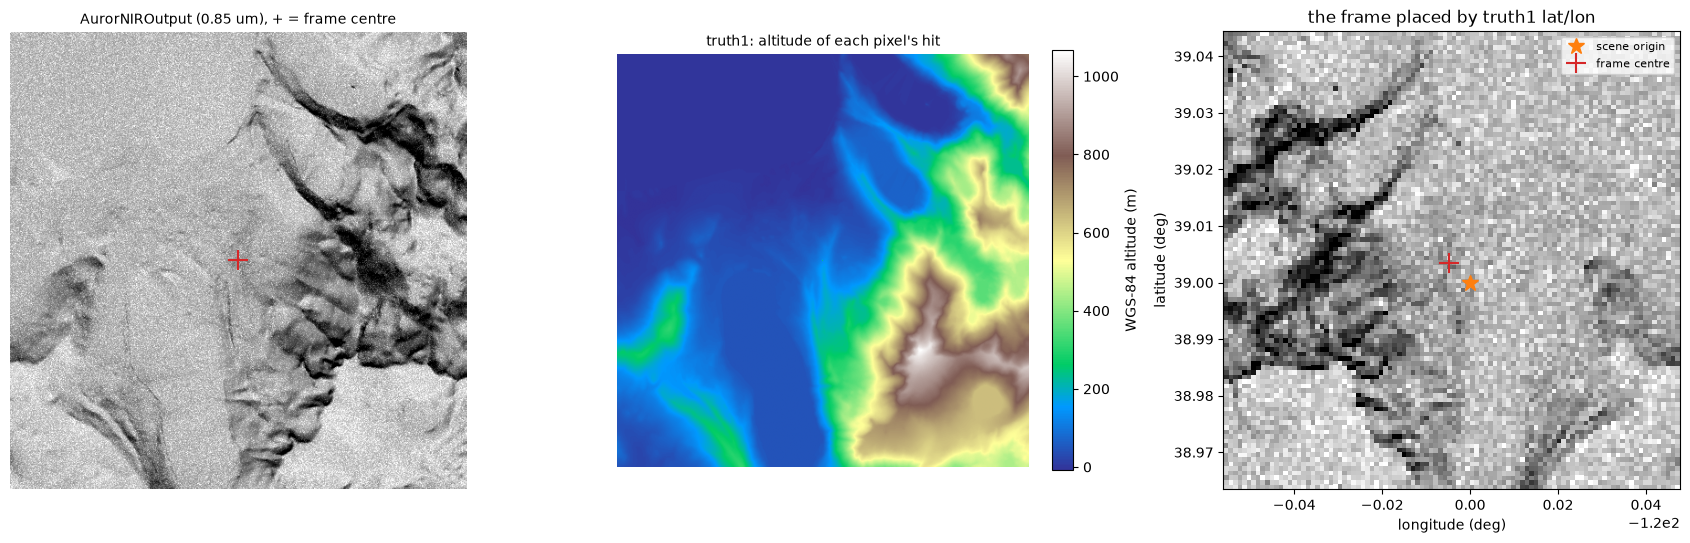

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from skyfield.api import wgs84
from spectral import open_image
from protodirsig import orbit

img = open_image(str(OUT_DIR / "AurorNIROutput.img.hdr"))
rad = np.asarray(img.load(), dtype=float)[:, :, 0]
tr = open_image(str(OUT_DIR / "truth1.img.hdr"))
truth = {n: np.asarray(tr.read_band(i), dtype=float) for i, n in enumerate(tr.metadata["band names"])}
lat, lon, alt = (truth[k] for k in ("Geodetic Latitude [degrees +N]", "Geodetic Longitude [degrees +E]", "WGS84 Altitude [m]"))
ecef = np.dstack([truth[f"ECEF {a} Coordinate [m]"] for a in "XYZ"])

print(f"image  : {rad.shape}, {img.metadata['data units']}, band {img.metadata['band names']} at "
      f"{img.metadata['wavelength']} um; acquisition {img.metadata['acquisition time']}")
print(f"radiance range {rad.min():.3e} .. {rad.max():.3e}, median {np.median(rad):.3e}")
c = rad.shape[0] // 2
e, n, u = orbit.ecef_to_enu_matrix(LAT0, LON0) @ (ecef[c - 1:c + 1, c - 1:c + 1].reshape(-1, 3).mean(0)
                                                  - wgs84.latlon(LAT0, LON0, elevation_m=ALT0).itrs_xyz.m)
print(f"frame centre hits scene ENU ({e:.1f}, {n:.1f}, {u:.1f}) m; terrain in frame {np.nanmin(alt):.0f}..{np.nanmax(alt):.0f} m")
km_n = (lat.max() - lat.min()) * 111.0
km_e = (lon.max() - lon.min()) * 111.0 * np.cos(np.radians(LAT0))
print(f"footprint {km_e:.1f} km E-W x {km_n:.1f} km N-S (~{km_e * 1e3 / rad.shape[1]:.0f} m pixels); misses {np.isnan(alt).sum()}")

fig, ax = plt.subplots(1, 3, figsize=(17, 5.4))
lo_, hi_ = np.percentile(rad, [1, 99])
ax[0].imshow(rad, cmap="gray", vmin=lo_, vmax=hi_)
ax[0].plot(c - 0.5, c - 0.5, "+", color="C3", ms=14, mew=1.5)
ax[0].set_title("AurorNIROutput (0.85 um), + = frame centre", fontsize=10); ax[0].axis("off")
m = ax[1].imshow(alt, cmap="terrain")
plt.colorbar(m, ax=ax[1], fraction=0.046, label="WGS-84 altitude (m)")
ax[1].set_title("truth1: altitude of each pixel's hit", fontsize=10); ax[1].axis("off")
ax[2].pcolormesh(lon[::5, ::5], lat[::5, ::5], rad[::5, ::5], cmap="gray", vmin=lo_, vmax=hi_, shading="auto")
ax[2].plot(LON0, LAT0, "*", color="C1", ms=12, label="scene origin")
ax[2].plot(lon[c, c], lat[c, c], "+", color="C3", ms=14, mew=1.5, label="frame centre")
ax[2].set(xlabel="longitude (deg)", ylabel="latitude (deg)", title="the frame placed by truth1 lat/lon")
ax[2].set_aspect(1 / np.cos(np.radians(LAT0))); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
assert np.hypot(e + 400, n - 400) < 18 and not np.isnan(alt).any()

**Reading the result.** The frame is the Tahoe terrain tile seen from straight above. All of it
is one grey material, so the contrast comes from relief: slope and shading. Fine pixel-to-pixel
grain is the renderer's Monte Carlo sampling noise. The truth image places every pixel on the
ground (no misses), with the frame centre directly under the sensor at scene `(-400, 400)`.
In the raw frame, row 0 is north but **column 0 is east**, so as rendered (pose yaw π, as
received) the image is mirror-imaged east to west compared with a map. The
third panel uses the truth latitude and longitude to place it correctly. (Checked from
`truth1`: longitude decreases from column 0 to column 499.)

**The vehicle target does not appear in this render.** The scene's 1500 K vehicle, 50 km up and
on the line of sight through the frame centre, is not visible there or anywhere else in the
frame. The image is bare terrain. The shipped 2025.51 render shows the same, so this belongs to
the received configuration, not this install. The investigation, and the candidate causes, are
in FINDINGS.md ("2026-10-06 — Phase 5").